**Autor: Emilio Hermosa Schiantarelli**

**Correo: 100451150@alumnos.uc3m.es**

**NIA: 100451150**



# Parte 1: Estudiando la red

## Ejercicio 1

El primer ejercicio es responder a las siguientes preguntas:

- ¿Cuántos generadores tiene la red, y en qué nodos están conectados?
- ¿Qué valores de potencia activa P(MW) tienen los generadores? 
- ¿Cuántas cargas tiene la red, y en qué nodos están conectados?

### Importar librerías
El primer paso de la práctica es importar las librerías recomendadas en el pdf. Para evitar errores, se crea previamente una celda para instalar las librerías en caso de no tenerlas instaladas.

In [9]:
%pip install seaborn matplotlib torch torch_geometric pandapower numpy


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle
import torch
import torch_geometric
import pandapower as pp
import numpy as np
import pandapower.networks as pn
import pandapower.plotting as plot
import matplotlib.lines as mlines

### Exploración de la red
El siguiente paso es explorar la red eléctrica que da la librería pandapower. Además muestro su contenido para hacerme una idea de que es lo que tiene

In [11]:
net = pn.case14 ()
net

This pandapower network includes the following parameter tables:
   - bus (14 elements)
   - load (11 elements)
   - gen (4 elements)
   - shunt (1 element)
   - ext_grid (1 element)
   - line (15 elements)
   - trafo (5 elements)
   - poly_cost (5 elements)

Esto muestra exactamente la información que se esperaba obtener según el pdf. Para obtener una mejor comprensión de los datos se ha buscado lo que representa cada uno dado que el pdf solo explicaba algunos de ellos. 

En concreto cada elemento es:
- bus (14): Los nodos de la red, puntos donde se conectan los demás elementos
- load (11): Las cargas, es decir, los consumidores de energía conectados a la red
- gen (4): Los generadores que inyectan potencia activa a la red
- shunt (1): Elemento conectado entre un nodo y tierra que compensa la potencia reactiva
- ext_grid (1): La conexión a una red externa, actúa como nodo Slack de referencia infinita
- line (15): Los cables de alta tensión que conectan unos buses con otros
- trafo (5): Los transformadores que cambian el nivel de tensión entre dos buses
- poly_cost (5): Los coeficientes del coste económico de generación de cada generador (función polinómica €/MW)

### Indexación por clave
El siguiente paso descrito es indexar por la clave para obtener un dataframe con todos los elementos de una categoría concreta. En el ejemplo se indexa por **gen** así que se sigue la misma lógica. También se indexara por **load** ya que el objetivo de este apartado es resolver varias preguntas sobre generadores y cargas.

In [ ]:
net['gen']

,name,bus,p_mw,vm_pu,sn_mva,min_q_mvar,max_q_mvar,scaling,slack,in_service,slack_weight,type,controllable,max_p_mw,min_p_mw,id_q_capability_characteristic,reactive_capability_curve,curve_style
0,None,1,40.0,1.045,NaN,-40.0,50.0,1.0,False,True,0.0,None,True,140.0,0.0,<NA>,False,None
1,None,2,0.0,1.010,NaN,0.0,40.0,1.0,False,True,0.0,None,True,100.0,0.0,<NA>,False,None
2,None,5,0.0,1.070,NaN,-6.0,24.0,1.0,False,True,0.0,None,True,100.0,0.0,<NA>,False,None
3,None,7,0.0,1.090,NaN,-6.0,24.0,1.0,False,True,0.0,None,True,100.0,0.0,<NA>,False,None


Se explora **load** para tener en cuenta no solo los generadores conectados a la red (**gen**) sino también las cargas (**load**).

In [13]:
net['load']

,name,bus,p_mw,q_mvar,const_z_p_percent,const_z_q_percent,const_i_p_percent,const_i_q_percent,sn_mva,scaling,in_service,type,controllable
0,None,1,21.7,12.7,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False
1,None,2,94.2,19.0,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False
2,None,3,47.8,-3.9,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False
3,None,4,7.6,1.6,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False
4,None,5,11.2,7.5,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False
5,None,8,29.5,16.6,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False
6,None,9,9.0,5.8,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False
7,None,10,3.5,1.8,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False
8,None,11,6.1,1.6,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False
9,None,12,13.5,5.8,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False



**Item 1:** Responde a las preguntas.

Gracias a estas dos tablas mostradas se pueden extraer las respuestas a las preguntas del ejercicio:

**¿Cuántos generadores tiene la red, y en qué nodos están conectados?**

Según la primera tabla se puede ver como la clase **net** tiene cuatro generadores. Además, la columna **bus** indica a que nodo está conectado, por lo tanto se puede ver que el generador 0 está conectado al nodo 1, el generador 1 al nodo 2, el generador 2 al nodo 5 y el generador 3 al nodo 7.

**¿Qué valores de potencia activa P(MW) tienen los generadores?**

En este estado base además, se puede ver en la columna **p_mw** de la primera tabla como únicamente el generador 0 tiene un valor de potencia distinto a 0. Mientras que los generadores 1, 2 y 3 tienen el valor de potencia igual a 0 para el generador 0 la potencia es de 40(MW).

**¿Cuántas cargas tiene la red, y en qué nodos están conectados?**

Por otro lado la segunda tabla muestra la cantidad de cargas que tiene la red, que son 11 (de 0 a 10) y están conectados a los nodos 1, 2,  3, 4, 5, 8, 9, 10, 11, 12 y 13 respectivamente. En este caso todas las cargas tienen un **p_mw** asociado mayor a 0.

## Ejercicio 2

El segundo ejercicio consiste en hacer una representación gráfica de la red. Para ello se utilizan la librería **pandapower.plotting** en combinación con el método simple_plot(). Además se incluyen todos los elementos posibles de la red. En concreto se mostrarán:
- **Buses (nodos)**: puntos de interconexión / subestaciones.
- **Líneas/Trafo**: conexiones de alta tensión entre buses.
- **Generadores** (PV): nodos con inyección de potencia activa.
- **Cargas**: nodos con consumo eléctrico.
- **Nodo Slack**: nodo de equilibrio del sistema.


Como se puede ver no están todos los elementos de la red específicamente ya que falta el **shunt**. Con la función **simple_plot()** no se puede hacer que se muestre este elemento específicamente. 

Si se quisiera hacer más elaboardo, dando notación a cada nodo o añadiendo **shunt** manualmente localizándolo en **net** se podría llegar a hacer pero es un trabajo costoso y no es lo que se busca en la práctica (se ha comentado con el profesor y se ha visto que esta alternativa, en la que se reperesenta únicamente lo que devuelve **simple_plot()** es la que se buscaba).

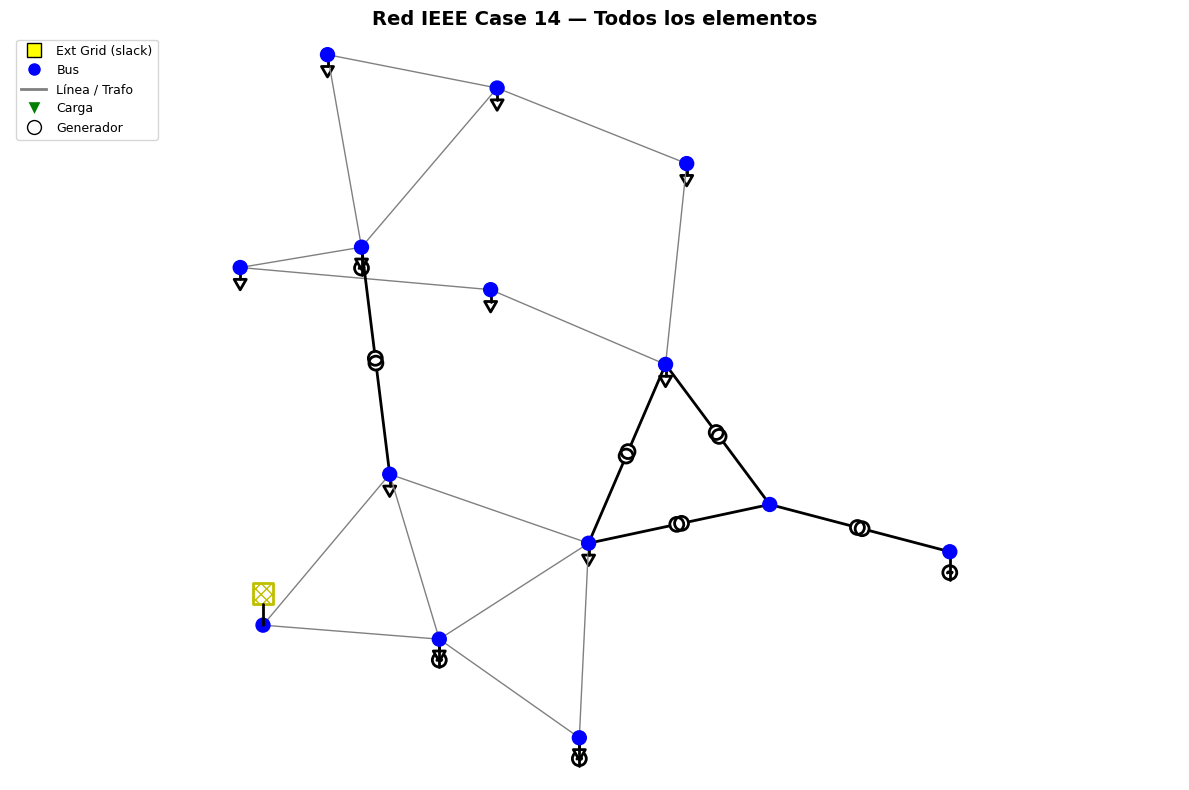

In [14]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plot principal con todos los parámetros disponibles
plot.simple_plot(
    net,
    plot_loads=True,          # Cargas 
    plot_gens=True,           # Generadores 
    plot_sgens=True,          # Generadores estáticos 
    plot_line_switches=True,  # Interruptores 
    show_plot=False,
    ax=ax
)

# Leyenda con formas
legend_elements = [
    mlines.Line2D([0], [0], marker='s', color='w', markerfacecolor='yellow', markeredgecolor='black', markersize=10, label='Ext Grid (slack)'),
    mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',   markersize=10, label='Bus'),
    mlines.Line2D([0], [0], color='grey',  linewidth=2,                                     label='Línea / Trafo'),
    mlines.Line2D([0], [0], marker='v', color='w', markerfacecolor='green',  markersize=10, label='Carga'),
    mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='black', markersize=10, label='Generador'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

ax.set_title("Red IEEE Case 14 — Todos los elementos", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Conclusiones

Se puede ver como la representación muestra los 14 buses, las 15 líneas (en gris) y los 5 transformadores (en negro más grueso), coincidiendo con la descripción inicial que había mostrado al principio del notebook. Nótese que pueden haber elementos solapados, por lo que puede ser complicado encontrar todos los elementos. Aún así es la mejor representación que he encontrado ya que inicialmente lo había hecho por colores y no se distinguía bien o se solapaban haciendo más difícil que se encontrara cada elemento.

El ext_grid aparece automáticamente en la esquina inferior izquierda sin necesidad de especificarlo, lo que confirma que **simple_plot()** lo incluye siempre por defecto al ser el nodo de referencia del sistema.

Al ver la red se puede comprobar que no es una red regular sino todo lo contrario, tiene zonas más estructuradas y otras más irregulares.

Por último, se observa que varios elementos quedan superpuestos sobre el mismo bus (por ejemplo, un generador y una carga en el mismo nodo), lo que dificulta la lectura visual pero refleja la realidad de nodos que generan y consumen energía a la vez.

##  Ejercicio 3

**Item 3:** A partir de lo indicado arriba, determina a qué tipo de nodo/bus de la red: PV, PQ o slack.

Clasificación de los Nodos de la Red
En una red eléctrica existen **tres tipos de nodos**, cada uno con un rol distinto:

| Tipo | Nombre |
|------|--------|
| **Slack** | Nodo de referencia / equilibrio |
| **PV** | Nodo generador |
| **PQ** | Nodo de carga |

Esta distinción es **crucial** para el modelo de aprendizaje automático:
- Determina qué variables se usan como **entrada** (condiciones conocidas).
- Determina qué variables deben ser **predichas** por la GNN.

Dado lo que se comenta en el enunciado sobre los tipos de nodos y las definiciones de **extr_grid**, **gen** y **load** que se han mencionado al inicio del cuaderno, puedo deducir que los nodos de tipo **Slack** se buscarán en **net['ext_grid']['bus']** ya que es el que actúa como nodo de equilibrio. Por otro lado para **PV** se buscará en **net['gen']['bus']** dado que representa nodos que tienen generadores conectados. Por último, los nodos dónde se consume energía eléctrica (**PQ**) se encuentra en el resto de casos.

**Nota**: Esta información ha sido extraída del enunciado.

### Simulación de flujo de cargas

Antes de proceder con la clasificación de elementos, se hace un análisis básico inicial de lo que se comenta en el pdf para hacer una simulación del flujo de cargas. De esta manera podré entender mejor que significa cada tipo de nodo y espero poder corroborar que la forma adecuada para clasificar los nodos es la que se ha comentado al principio del apartado mediante la distinción entre **net['ext_grid']['bus']**, **net['gen']['bus']** y el resto.

In [15]:
pp.runpp(net)
net.res_bus

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


,vm_pu,va_degree,p_mw,q_mvar
0,1.060000,0.000000,-232.393272,16.549301
1,1.045000,-4.982589,-18.300000,-30.857100
2,1.010000,-12.725100,94.200000,-6.075348
3,1.017671,-10.312901,47.800000,-3.900000
4,1.019514,-8.773854,7.600000,1.600000
5,1.070000,-14.220946,11.200000,-5.230944
6,1.061520,-13.359627,0.000000,0.000000
7,1.090000,-13.359627,0.000000,-17.623451
8,1.055932,-14.938521,29.500000,-4.584844
9,1.050985,-15.097288,9.000000,5.800000


Se puede observar que el único nodo con **va_degree** igual a 0 es el nodo 0 (**slack**).  Además, se puede ver que tiene **p_mw** con un valor muy distinto al resto de **-232.39** que refleja que es el principal nodo que suministra energía a la red. 

Por otro lado se puede ver que la columna **vm_pu** tiene varios valores que aparentemente están fijados como son los nodos 0, 1, 2, 5 o 7, ya que a diferencia del resto que tiene valores con muchos decimales, las tensiones de estos nodos tienen valores con pocos decimales. Según el enunciado, la tensión (**vm_pu**) tiene valores fijos para **Slack** o **PV** mientras que son predichos para el resto, por lo tanto cuadra que los nodos con valores prefijados corresponden con **Slack** o **PV**. Además, estos nodos como veíamos al principio del notebook corresponden con los nodos de **ext_grid** y de **gen** corroborando así lo que se comentaba al inicio del apartado sobre como diferenciar los tipos de nodos.

Por lo tanto, dado que el nodo 0 (el cual es el **ext_grid**) tiene desfase constante igual a 0 y es uno de los nodos con tensión constante, se ha determinado que es el nodo **Slack**.

Los nodos que habíamos determinado en el apartado 1 que son los nodos **gen** son los que tienen tensiones fijas y desfases variables por lo que son los nodos de tipo **PV**.

Por último, el resto de nodos son los nodos **PQ**.

Tras la simulación se procede a clasificar los nodos en base a lo comentado al principio del apartado.

In [16]:
# Regla:
# Bus slack: aparece en net['ext_grid']['bus']
# Buses PV: aparecen en net['gen']['bus']
# Buses PQ: el resto (solo tienen cargas o nada conectado)

bus_type = {}  

for bus in net.bus.index:
    if bus in net['ext_grid']['bus'].values:
        bus_type[bus] = 'Slack'
    elif bus in net['gen']['bus'].values:
        bus_type[bus] = 'PV'
    else:
        bus_type[bus] = 'PQ'

for bus, tipo in bus_type.items():
    print(f"Bus {bus:>2} → {tipo}")

Bus  0 → Slack
Bus  1 → PV
Bus  2 → PV
Bus  3 → PQ
Bus  4 → PQ
Bus  5 → PV
Bus  6 → PQ
Bus  7 → PV
Bus  8 → PQ
Bus  9 → PQ
Bus 10 → PQ
Bus 11 → PQ
Bus 12 → PQ
Bus 13 → PQ


**Item 4:** Guardar dataset

## Ejercicio 4

### 4.1 Generación del dataset

Se genera el dataset en base a las especificaciones del enunciado. Dado que se ha hecho antes **pp.runpp** sobre **net** se crea una nueva instancia llamada **net_base** para generar el dataset sobre los datos originales.

In [ ]:
# Generación del dataset: N = 5000 simulaciones

N_TARGET    = 5000
ALPHA_LOW   = 0.7
ALPHA_HIGH  = 1.3

# Valores base (caso sin perturbar)
net_base = pn.case14()

p_load_base  = net_base['load']['p_mw'].values.copy()
q_load_base  = net_base['load']['q_mvar'].values.copy()
p_gen_base   = net_base['gen']['p_mw'].values.copy()

results = []     # lista donde almacenaremos cada simulación exitosa
n_converged  = 0
n_diverged   = 0

rng = np.random.default_rng(seed=42)  # semilla para reproducibilidad

while n_converged < N_TARGET:
    # Perturbación aleatoria de cargas
    alpha_load = rng.uniform(ALPHA_LOW, ALPHA_HIGH, size=len(p_load_base))
    net_base['load']['p_mw']   = p_load_base  * alpha_load
    net_base['load']['q_mvar'] = q_load_base  * alpha_load

    # Perturbación aleatoria de generadores
    alpha_gen = rng.uniform(ALPHA_LOW, ALPHA_HIGH, size=len(p_gen_base))
    net_base['gen']['p_mw']    = p_gen_base   * alpha_gen

    # Ejecución del flujo de cargas
    try:
        pp.runpp(net_base, numba=False)
    except Exception:
        n_diverged += 1
        continue

    if not net_base.converged:
        n_diverged += 1
        continue

    #  Guardar resultado
    results.append({
        'p_load':  net_base['load']['p_mw'].values.copy(),
        'q_load':  net_base['load']['q_mvar'].values.copy(),
        'p_gen':   net_base['gen']['p_mw'].values.copy(),
        'res_bus': net_base.res_bus[['p_mw', 'q_mvar', 'vm_pu', 'va_degree']].values.copy()
    })
    n_converged += 1

    if n_converged % 500 == 0:
        print(f"{n_converged}/{N_TARGET} (descartadas: {n_diverged})")

print(f"\nTotal: {n_converged} convergentes, {n_diverged} descartadas.")

500/5000 (descartadas: 0)
1000/5000 (descartadas: 0)
1500/5000 (descartadas: 0)
2000/5000 (descartadas: 0)
2500/5000 (descartadas: 0)
3000/5000 (descartadas: 0)
3500/5000 (descartadas: 0)
4000/5000 (descartadas: 0)
4500/5000 (descartadas: 0)
5000/5000 (descartadas: 0)

Total: 5000 convergentes, 0 descartadas.


### 4.2 Construcción del dataset

A continuación se sigue el mismo procedimiento que se explica en el enunciado. 


El primer paso va a ser una codificación de valores. Los tipos que han sido anteriormente definido se va a codificar a números para trabajar más fácilmente con ello. En concreto el enunciado dice que el vector de características de entrada tenga la siguiente forma:
$$x_{i,n} = [P_{i,n},\ Q_{i,n},\ V^{set}_{i,n},\ tipo_i], \quad tipo_i \in \{0,1\}^3$$

Por lo tanto **tipo** se trata como una lista de binarios donde representa [**PQ**, **PV**, **Slack**] y por lo tanto, si la lista es [1,0,0] indica que el tipo es **PQ** si es [0,1,0] indica que es **PV** y [0,0,1] indica que es **Slack**.

Además se guarda en un nuevo diccionario aquellos valores de **vm_pu** (tensiones) que están prefijadas (es decir que corresponden a **PV** o **Slack**).

**Nota**: Se crea **net_ref** como una instancia limpia de la red IEEE case 14 para consultar información estructural, las tensiones fijadas en nodos **PV** y **slack** y la topología de conexiones entre buses. Aunque el bucle de simulación no modifica estos valores, usar un objeto de referencia intacto es una buena práctica para separar claramente los datos de entrada estructurales de los resultados de cada simulación. se comentó con el profesor y se concluyyó que era buena idea aunque no necesaria, por ello se ha decidido hacer así aunqe se pudiera haber usado la red anterior.

In [ ]:
# Mapeo de tipos de nodo a one-hot encoding
# PQ: [1, 0, 0]
# PV: [0, 1, 0]
# Slack: [0, 0, 1]

type_code = {}
for bus, tipo in bus_type.items():
    if tipo == 'PQ':
        type_code[bus] = [1, 0, 0]
    elif tipo == 'PV':
        type_code[bus] = [0, 1, 0]
    else:  # Slack
        type_code[bus] = [0, 0, 1]

# Tensiones fijadas (nodos PV y Slack)
net_ref = pn.case14()
v_set_by_bus = {}

for _, row in net_ref['gen'].iterrows():
    v_set_by_bus[row['bus']] = row['vm_pu']

for _, row in net_ref['ext_grid'].iterrows():
    v_set_by_bus[row['bus']] = row['vm_pu']

Tras la transformación inicial se pueden crear los dos sets especificados en el enunciado tal y como se explica:
- X: variables de entrada (condiciones de la red)
- Y : variables de salida (estado de la red)

Además se toma en consideración lo siguiente explicado en el enunciado:

*Dado que no todas las variables están definidas para todos los tipos de nodo, se emplean valores nulos (cero) como placeholders*

Por lo tanto queda de la siguiente forma para las variables de entrada y salida:
$$x_{i,n} = [P_{i,n},\ Q_{i,n},\ V^{set}_{i,n},\ tipo_i], \quad tipo_i \in \{0,1\}^3$$

$$y_{i,n} = [V_{i,n},\ \delta_{i,n}]$$

Con los placeholders de la siguiente manera:

| Tipo de nodo | $P_i$ | $Q_i$ | $V^{set}_i$ |
|---|---|---|---|
| PQ | inyección neta | inyección neta | 0 |
| PV | inyección neta | 0 | tensión fijada |
| Slack | 0 | 0 | tensión fijada |

**Nota**: Tanto las fórmulas como la tabla han sido extraídas del pdf. No se ha especificado lo que significa cada variable porque ya viene en el pdf y sería redundante tanta información repetida.


In [ ]:
N = len(results)
n_buses = len(net_ref.bus)

X_list = []
Y_list = []

for sim in results:
    res_bus = sim['res_bus'] 

    x_sim = np.zeros((n_buses, 6), dtype=np.float32)
    y_sim = np.zeros((n_buses, 2), dtype=np.float32)

    for bus in net_ref.bus.index:
        onehot = type_code[bus]  # [1,0,0] / [0,1,0] / [0,0,1]
        p      = res_bus[bus, 0]
        q      = res_bus[bus, 1]
        v      = res_bus[bus, 2]
        delta  = res_bus[bus, 3]

        if onehot == [1, 0, 0]:    # PQ
            x_sim[bus] = np.concatenate([[p, q, 0.0], onehot])
        elif onehot == [0, 1, 0]:  # PV
            v_set = v_set_by_bus[bus]
            x_sim[bus] = np.concatenate([[p, 0.0, v_set], onehot])
        else:                      # Slack
            v_set = v_set_by_bus[bus]
            x_sim[bus] = np.concatenate([[0.0, 0.0, v_set], onehot])

        y_sim[bus] = [v, delta]

    X_list.append(x_sim)
    Y_list.append(y_sim)

X = torch.tensor(np.stack(X_list), dtype=torch.float32)   # (N, 14, 6)
Y = torch.tensor(np.stack(Y_list), dtype=torch.float32)   # (N, 14, 2)

Se ha decidido hacer una representación básica de las distribuciones de tensiones y de ángulos de desfase (variables objetivo) para comprobar el estado del dataset objetivo actual.

Dado que no se quiere hacer un análisis exploratorio descriptivo exhaustivo sino más bien uan idea de lo realizado, se ha focalizado esta sección a estudiar la distribución de las variables objetivo que tienen más sentido exploratorio ya que son las variables que el modelo tiene que predecir.

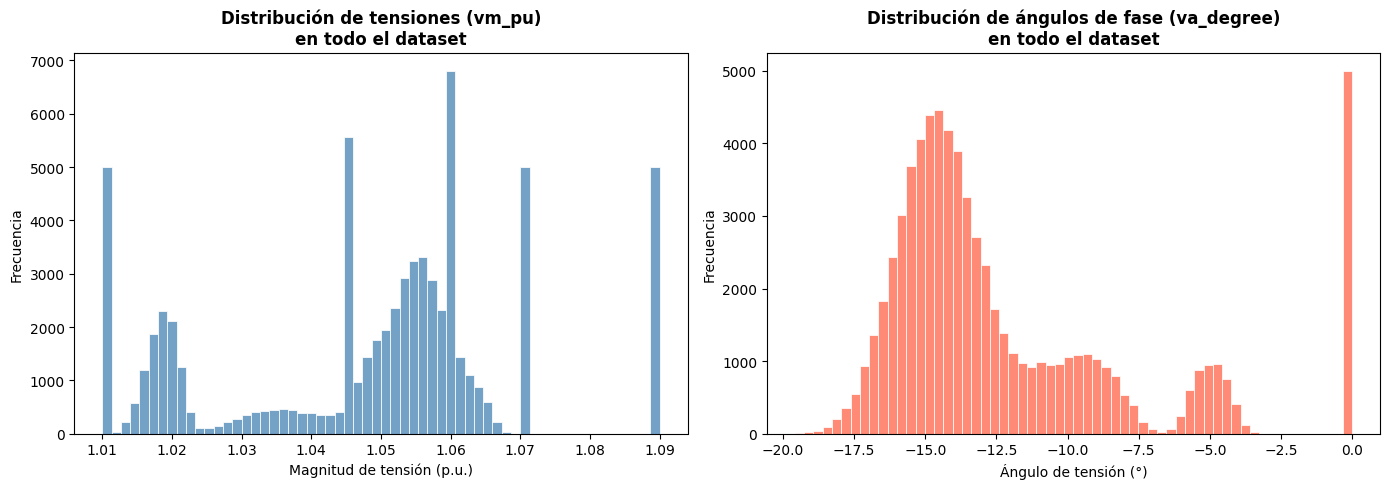

In [ ]:
# Estadísticas descriptivas del dataset 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de tensiones (vm_pu) en todas las muestras y nodos
ax1 = axes[0]
vm_all = Y[:, :, 0].numpy().flatten()
sns.histplot(vm_all, bins=60, ax=ax1, color='steelblue', edgecolor='white')
ax1.set_title("Distribución de tensiones (vm_pu)\nen todo el dataset", fontweight='bold')
ax1.set_xlabel("Magnitud de tensión (p.u.)")
ax1.set_ylabel("Frecuencia")

# Distribución de ángulos de fase (va_degree)
ax2 = axes[1]
va_all = Y[:, :, 1].numpy().flatten()
sns.histplot(va_all, bins=60, ax=ax2, color='tomato', edgecolor='white')
ax2.set_title("Distribución de ángulos de fase (va_degree)\nen todo el dataset", fontweight='bold')
ax2.set_xlabel("Ángulo de tensión (°)")
ax2.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

#### Conclusiones

Aunque para este apartado no son necesarias, se ha querido hacer un breve apartado de conclusiones para mencionar ciertos puntos interesantes que se pueden remarcar de las dos gráficas de distribuciones.

**Distribución de tensiones**:
- Se pueden ver las tensiones fijadas que se comentaban de **Slack** y de **PV** en las barras verticales que se destacan respecto a las otras de la distribución (que son las que tienen valores no fijados de **PQ**).

**Distribuciones de ángulos de fase**:
- Se puede ver en 0º una barra aislada que corresponde al **Slack**. Se sabe que es del **Slack** ya que en la documentación extra [Power Flow](https://en.wikipedia.org/wiki/Power-flow_study) que se menciona en el PDF dice que la fase en **Slack** es conocida por lo que no es calculada sino que es un valor fijo constante, lo cual cuadra con la recta vertical larga en 0º.

### 4.3 Topología de la red

El último apartado de la primera parte es estudiar la conexión directa entre nodos para poder crear un modelo que integre la conectividad de la red. Para ello se crea un grafo no dirigido en el que cada arista representa una línea de alta tensión o un transformador que conecta dos nodos. Al ser no dirigido, cada conexión entre nodos $i$ y $j$ se incluye en ambas direcciones [$i, j$] y [$j, i$].

In [21]:
edges_src = []
edges_dst = []

for _, row in net_ref['line'].iterrows():
    i, j = int(row['from_bus']), int(row['to_bus'])
    edges_src += [i, j]
    edges_dst += [j, i]

for _, row in net_ref['trafo'].iterrows():
    i, j = int(row['hv_bus']), int(row['lv_bus'])
    edges_src += [i, j]
    edges_dst += [j, i]

edge_index = torch.tensor([edges_src, edges_dst], dtype=torch.long)

for k in range(0, edge_index.shape[1], 2):
    print(f"{edge_index[0, k].item()} — {edge_index[1, k].item()}")

0 — 1
0 — 4
1 — 2
1 — 3
1 — 4
2 — 3
3 — 4
5 — 10
5 — 11
5 — 12
8 — 9
8 — 13
9 — 10
11 — 12
12 — 13
3 — 6
3 — 8
4 — 5
6 — 7
6 — 8


Se muestran las conexiones del grafo. Para no ver las conexiones repetidas (ya que se guarda en el grafo [$i, j$] y [$j, i$]) se muestra solo una vez pero en **edge_index** como se comentaba se han añadido las conexiones en ambas direcciones [$i, j$] y [$j, i$]

### 4.4 Guardado de datos
El último paso es agrupar las muestras $\{(X_i, Y_i)\}_{i=1}^{N}$ que se han hecho antes junto al nuevo grafo **edge_index**. Se guarda todo en un diccionario para crear un fichero con dicha información.

In [22]:
dataset = {
    'X': X,
    'Y': Y,
    'edge_index': edge_index
}

with open('dataset.pkl', 'wb') as f:
    pickle.dump(dataset, f)

# Parte 2: Modelado y entrenamiento con redes

**Nota:** Aunque se han realizado en dos etapas distintas la parte uno y dos de este cuaderno, se han reutilizado algunas variables definidas en la primera parte (**Parte 1: Estudiando la red**) para esta segunda parte. Por lo tanto si se intenta ejecutar esta parte sin haber ejecutado previamente la primera habrá errores. 

### Importar librerías

Se importan las nuevas librerías que son necesarias para esta parte y no han sido importadas anteriormente.

In [ ]:
# Importaciones adicionales para la Parte 2
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split

### Cargar dataset

Dado que se han guardado **X**, **Y** y **edge_index** en un fichero llamado **dataset.pkl** ahora se cargan los datos recogidos y guardados en dicho fichero.

In [ ]:
# Cargar dataset guardado en la Parte 1
with open('dataset.pkl', 'rb') as f:
    dataset = pickle.load(f)
X          = dataset['X']           # (N, 14, 6)
Y          = dataset['Y']           # (N, 14, 2)
edge_index = dataset['edge_index']  # (2, 2E)

N       = X.shape[0]
N_BUSES = X.shape[1]

print(f"X shape:          {X.shape}   → (muestras, nodos, features)")
print(f"Y shape:          {Y.shape}   → (muestras, nodos, salidas)")
print(f"edge_index shape: {edge_index.shape}")

X shape:          torch.Size([5000, 14, 6])   → (muestras, nodos, features)
Y shape:          torch.Size([5000, 14, 2])   → (muestras, nodos, salidas)
edge_index shape: torch.Size([2, 40])


## Ítem 5: Arquitectura de la GNN y Entrenamiento

### Diseño

El primer apartado de la práctica consiste en el diseño de una arquitectura basada en redes neuronales de grafos. Para ello se debe realizar un diagrama de la arquitectura. Dada la naturaleza de la práctica se ha decidido mantener el uso de capas de grafo convolucionales (**GCN**) dado que son las que vienen predefinidas y se quiere estudiar sus capacidades. Se podrían usar otros modelos más sofisticados basados en mecanismos de atención como **GAT** pero para un primer contacto con redes neuronales de grafos se ha preferido mantener una estructura simple para consolidar mejor las bases de este tipo de redes. 

Además, se ha decidido usar activaciones ReLU entre capas exceptuando la de salida, ya que en otras arquitecturas de redes neuronales lo había hecho así.


**Motivación del diseño:**
- Mantener la simplicidad para poder consolidar las bases e interiorizar mejor el concepto de redes neuronales de grafos. Por ello se ha decidido hacer uso de GCN.
- La red eléctrica IEEE Case 14 es similar a un grafo: los buses son nodos y las líneas/transformadores son aristas. GCN puede modelar esta arquitectura sin mucha dificultad.
- GCN agrega información de los nodos vecinos en cada capa, lo que refleja la dependencia física entre buses adyacentes en el flujo de cargas: el estado de un nodo depende de sus vecinos.
- Con 3 capas, la información se propaga hasta 3 saltos, cubriendo la mayor parte de la red y haciendo el modelo más simple, lo que ayuda a evitar sobreajuste. 

**Entrada por nodo:** $x_i = [P_i,\, Q_i,\, V^{set}_i,\, \text{tipo}_{PQ},\, \text{tipo}_{PV},\, \text{tipo}_{Slack}] \in \mathbb{R}^6$

**Salida por nodo:** $\hat{y}_i = [\hat{V}_i,\, \hat{\delta}_i] \in \mathbb{R}^2$

- Por defecto se espera un vector de 6 característas (P, Q, V_set,  vector one-hot tipo) y la salida es un vector de 2 elementos (V y delta). Además, la capa oculta tiene 64 canales. Aunque parece a priori un valor elevado, se ha comprobado que funciona correctamente y se obtienen los resultados esperados con este valor.

**Nota**: Se han probado distintas arquitecturas, con más capas, con más o menos canales, etc. Con esta arquitectura final se obtuvieron resultados satisfactorios manteniendo un número bajo de capas, reduciendo así la complejidad del modelo. Se probó a normalizar los datos entre capas con BatchNorm, pero era problemático y daba peores resultados que sin añadir entre capas la normalización, por lo que se ha decidido prescindir de ello y solo normalizar al principio.

### Diagrama de la arquitectura

Dado que este apartado pide explícitamente un diagrama de la arquitectura empleada, se ha decidido representar dicho diagrama a través de código aprovechando la librería **matplotlib** que es muy útil para representaciones. 

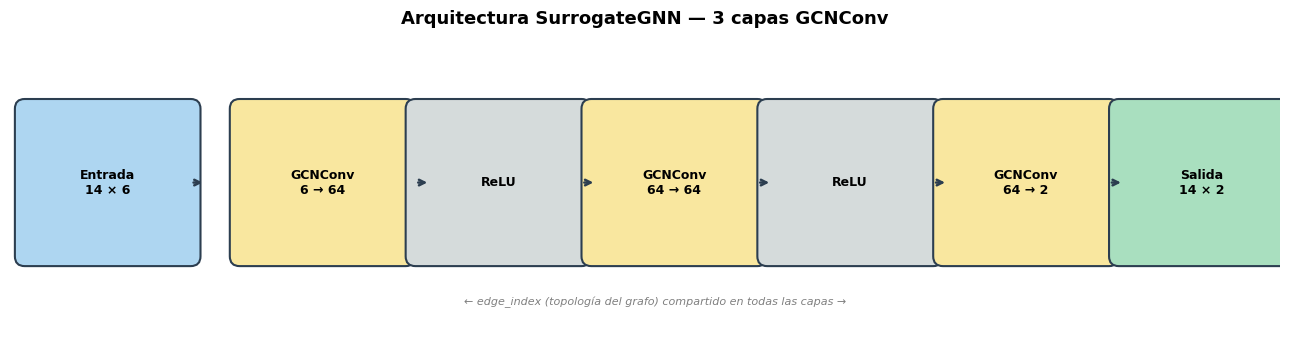

In [ ]:
# Diagrama de la arquitectura
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 3)
ax.axis('off')

# Definición de bloques: (etiqueta, x_centro, color)
blocks = [
    ("Entrada\n14 × 6",        1.0,  '#AED6F1'),
    ("GCNConv\n6 → 64",        3.2,  '#F9E79F'),
    ("ReLU",              5.0,  '#D5DBDB'),
    ("GCNConv\n64 → 64",       6.8,  '#F9E79F'),
    ("ReLU",              8.6,  '#D5DBDB'),
    ("GCNConv\n64 → 2",       10.4,  '#F9E79F'),
    ("Salida\n14 × 2",        12.2,  '#A9DFBF'),
]

for label, xc, color in blocks:
    ax.add_patch(mpatches.FancyBboxPatch(
        (xc - 0.85, 0.75), 1.7, 1.5,
        boxstyle="round,pad=0.1",
        facecolor=color, edgecolor='#2C3E50', linewidth=1.5))
    ax.text(xc, 1.5, label, ha='center', va='center', fontsize=9, fontweight='bold')

# Flechas entre bloques
arrow_xs = [1.85, 4.15, 5.85, 7.65, 9.45, 11.25]
for xa in arrow_xs:
    ax.annotate('', xy=(xa + 0.15, 1.5), xytext=(xa, 1.5),
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.8))

# Nota sobre edge_index
ax.text(6.6, 0.25, '← edge_index (topología del grafo) compartido en todas las capas →',
        ha='center', fontsize=8, style='italic', color='gray')

ax.set_title("Arquitectura SurrogateGNN — 3 capas GCNConv", fontsize=13, fontweight='bold', pad=8)
plt.tight_layout()
plt.show()

Como se puede ver en el diagrama, la arquitectura de mi modelo estará compuesta por tres capas **GCN** con activaciones **ReLU** entre capas menos en la salida de la última capa que directamente es la salida del modelo.

Tras esto se crea una clase que representa esta arquitectura y que es la utilizada por mi modelo para la predicción de V y delta

### Definición del modelo
Se define la clase que se va a utilizar como red neuronal de grafos durante esta parte de la práctica usando de base la arquitectura explicada.

In [ ]:
# Definición del modelo SurrogateGNN 
class SurrogateGNN(nn.Module):
    """
    Red neuronal de grafos surrogada para el problema de flujo de cargas.
    Arquitectura: 3 capas GCNConv + ReLU.
      - Entrada:   6 features por nodo (P, Q, V_set, one-hot tipo)
      - Ocultas:   64 canales
      - Salida:    2 valores por nodo (V, delta)
    """
    def __init__(self, in_channels=6, hidden_channels=64, out_channels=2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))   # capa 1
        x = F.relu(self.conv2(x, edge_index))   # capa 2
        x = self.conv3(x, edge_index)                      # capa 3 (lineal)
        return x   # shape: (num_nodes, 2)

### Máscara binaria para la función de coste

En el enunciado se dice que se puede excluir de la función de costes lo siguiente dado que se conoce el valor de dichas características al ser constantes conocidas como se mencionó en la primera parte de la práctica:
- **Todas las salidas del nodo slack** (V y δ): son variables fijas y conocidas por definición.
- **El voltaje $V_i$ de los nodos PV**: la tensión en nodos **PV** es una variable conocida.

Según el enunciado esta exclusión es justificada de la siguiente manera:

*Esta exclusión es coherente con la formulación del problema físico, ya que dichas variables no son realmente desconocidas en el flujo de cargas*

Por lo tanto he construido una máscara binaria `mask` de forma `(14, 2)` donde todos los valores que se conocen y por tanto son constantes (V y δ de slack, V de PV) tienen valor 0 mientras que el resto cuyo valor es variable tiene valor de 1.

In [ ]:
# Máscara binaria: excluir slack (V y δ) y nodos PV (solo V)
mask = torch.ones(N_BUSES, 2, dtype=torch.float32)

slack_buses = [bus for bus, tipo in bus_type.items() if tipo == 'Slack']
pv_buses    = [bus for bus, tipo in bus_type.items() if tipo == 'PV']

for bus in slack_buses:
    mask[bus, :] = 0.0   # excluir V y δ del nodo slack

for bus in pv_buses:
    mask[bus, 0] = 0.0   # excluir Vi de nodos PV

print(f"{'Bus':>4} {'Tipo':>6} | {'V incluida':>10} {'δ incluida':>10}")
print("-" * 38)
for i in range(N_BUSES):
    tipo = bus_type[i]
    print(f"{i:>4} {tipo:>6} | {int(mask[i,0].item()):>10} {int(mask[i,1].item()):>10}")

n_valid = int(mask.sum().item())
print(f"\nTotal de salidas válidas por muestra: {n_valid} / {N_BUSES * 2}")

 Bus   Tipo | V incluida δ incluida
--------------------------------------
   0  Slack |          0          0
   1     PV |          0          1
   2     PV |          0          1
   3     PQ |          1          1
   4     PQ |          1          1
   5     PV |          0          1
   6     PQ |          1          1
   7     PV |          0          1
   8     PQ |          1          1
   9     PQ |          1          1
  10     PQ |          1          1
  11     PQ |          1          1
  12     PQ |          1          1
  13     PQ |          1          1

Total de salidas válidas por muestra: 22 / 28


Como se puede ver en el resultado de salida, los únicos 0 se aprecian en (V y δ) de **Slack** o en (V) de los nodos tipo **PV**

### Entrenamiento

Aunque el **item 5** del enunciado solo especifica explicar la arquitctura y crear un diagrama, se ha decidido unir ese apartado con el entrenamiento del modelo ya que el **Item 6** es directamente la comparación entre curvas de error de validación y entrenamiento. Por lo tanto para no crear secciones entre medias y dado que la explicación del entrenamiento se hace entre el **Item 5** y el **Item 6** se ha decidido continuar el apartado con el entrenamiento. 

Al ser tan explícita la descripción del enunciado de como entrenar, se han seguido las indicaciones fielmente, con la división pertinente en train/val/test, la normalización de los datos respecto al conjunto de entrenamiento y el entrenmiento posterior.

In [ ]:

# División aleatoria 80/20 (entrenamiento+validación / evaluación)
indices = torch.arange(N)

train_val_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
train_idx, val_idx      = train_test_split(train_val_idx, test_size=0.1, random_state=42)

X_train, Y_train = X[train_idx], Y[train_idx]
X_val,   Y_val   = X[val_idx],   Y[val_idx]
X_test,  Y_test  = X[test_idx],  Y[test_idx]

print(f"Entrenamiento: {len(train_idx)} muestras")
print(f"Validación:    {len(val_idx)} muestras")
print(f"Evaluación:    {len(test_idx)} muestras")

# Normalización con estadísticos del conjunto de entrenamiento
X_mean = X_train.reshape(-1, X_train.shape[-1]).mean(0)
X_std  = X_train.reshape(-1, X_train.shape[-1]).std(0) + 1e-8

Y_mean = Y_train.reshape(-1, Y_train.shape[-1]).mean(0)
Y_std  = Y_train.reshape(-1, Y_train.shape[-1]).std(0) + 1e-8

def normalize_X(Xt):    return (Xt - X_mean) / X_std
def normalize_Y(Yt):    return (Yt - Y_mean) / Y_std
def denormalize_Y(Yt):  return Yt * Y_std + Y_mean

X_train_n = normalize_X(X_train);  Y_train_n = normalize_Y(Y_train)
X_val_n   = normalize_X(X_val);    Y_val_n   = normalize_Y(Y_val)
X_test_n  = normalize_X(X_test);   Y_test_n  = normalize_Y(Y_test)

print("\nNormalización aplicada (media y std del conjunto de entrenamiento):")
print(f"  Y_mean: V={Y_mean[0]:.4f} p.u.   δ={Y_mean[1]:.4f}°")
print(f"  Y_std:  V={Y_std[0]:.4f}         δ={Y_std[1]:.4f}°")

Entrenamiento: 3600 muestras
Validación:    400 muestras
Evaluación:    1000 muestras

Normalización aplicada (media y std del conjunto de entrenamiento):
  Y_mean: V=1.0485 p.u.   δ=-12.0546°
  Y_std:  V=0.0211         δ=4.5719°


### Objetos data

El siguiente paso es la construcción de los objetos Data que se comentaba al inicio del enunciado de la parte 2 de la práctica. Esto se hace ahora porque es más interesante hacerlo con los datos ya normalizados y divididos. Además se ha ido modificando el **BATCH_SIZE** para obtener los mejores resultados posibles, por ello se ha acabado con un **BATCH_SIZE**=32 ya que era el que menos oscilaciones y perturbaciones generaba en la curva de error posterior para la validación.

Tras construir los objetos **Data**, se construye sobre cada conjunto un **DataLoader** para agrupar las muestras individuales en batches y de esta forma el modelo procesa varias muestras a la vez, haciendo el entrenamiento más eficiente.

In [ ]:
# Construcción de objetos Data (PyTorch Geometric)
# Cada muestra es un grafo: Data(x=Xi, y=Yi, edge_index=edge_index)

def build_data_list(X_norm, Y_norm, ei):
    return [Data(x=X_norm[i], y=Y_norm[i], edge_index=ei)
            for i in range(X_norm.shape[0])]

train_dataset = build_data_list(X_train_n, Y_train_n, edge_index)
val_dataset   = build_data_list(X_val_n,   Y_val_n,   edge_index)
test_dataset  = build_data_list(X_test_n,  Y_test_n,  edge_index)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches de entrenamiento: {len(train_loader)}")
print(f"Batches de validación:    {len(val_loader)}")
print(f"Batches de evaluación:    {len(test_loader)}")
print(f"\nEjemplo de objeto Data: {train_dataset[0]}")

Batches de entrenamiento: 113
Batches de validación:    13
Batches de evaluación:    32

Ejemplo de objeto Data: Data(x=[14, 6], edge_index=[2, 40], y=[14, 2])


### Entrenamiento y validación

El siguiente paso es el entrenamiento y la validación del modelo. Dado que el enunciado dice que se utilice la función de pérdida MSE, se ha decidido seguir las indicaciones. Aún así, se debe tener en cuenta la máscara creada anteriormente que se utiliza para calcular la pérdida en cada iteración.

In [ ]:
# Función de pérdida MSE enmascarada 
def masked_mse_loss(pred, target, mask):
    """
    MSE solo sobre las salidas válidas según la máscara binaria.
    pred, target: (B, N_BUSES, 2)
    mask:         (N_BUSES, 2)  — broadcast sobre dimensión batch
    """
    squared_error = (pred - target) ** 2          # (B, N_BUSES, 2)
    masked_error  = squared_error * mask           # zeros en entradas excluidas
    # Media sobre elementos válidos y muestras del batch
    return masked_error.sum() / (mask.sum() * pred.shape[0])

# Entrenamiento
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}\n")

model     = SurrogateGNN(in_channels=6, hidden_channels=64, out_channels=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
mask_dev  = mask.to(device)

EPOCHS       = 200
train_losses = []
val_losses   = []

for epoch in range(1, EPOCHS + 1):

    #  Fase de entrenamiento 
    model.train()
    total_train, n_train_samples = 0.0, 0
    for batch in train_loader:
        batch = batch.to(device)
        B     = batch.num_graphs
        optimizer.zero_grad()
        out    = model(batch.x, batch.edge_index)       
        pred   = out.view(B, N_BUSES, 2)
        target = batch.y.view(B, N_BUSES, 2)
        loss   = masked_mse_loss(pred, target, mask_dev)
        loss.backward()
        optimizer.step()
        total_train     += loss.item() * B
        n_train_samples += B
    epoch_train = total_train / n_train_samples

    #  Fase de validación 
    model.eval()
    total_val, n_val_samples = 0.0, 0
    with torch.no_grad():
        for batch in val_loader:
            batch  = batch.to(device)
            B      = batch.num_graphs
            out    = model(batch.x, batch.edge_index)
            pred   = out.view(B, N_BUSES, 2)
            target = batch.y.view(B, N_BUSES, 2)
            loss   = masked_mse_loss(pred, target, mask_dev)
            total_val     += loss.item() * B
            n_val_samples += B
    epoch_val = total_val / n_val_samples

    train_losses.append(epoch_train)
    val_losses.append(epoch_val)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Época {epoch:>3}/{EPOCHS}  |  Train MSE: {epoch_train:.6f}  |  Val MSE: {epoch_val:.6f}")

Dispositivo: cuda

Época   1/200  |  Train MSE: 0.171668  |  Val MSE: 0.076566
Época  20/200  |  Train MSE: 0.019916  |  Val MSE: 0.019795
Época  40/200  |  Train MSE: 0.010349  |  Val MSE: 0.010075
Época  60/200  |  Train MSE: 0.008796  |  Val MSE: 0.008423
Época  80/200  |  Train MSE: 0.008262  |  Val MSE: 0.008054
Época 100/200  |  Train MSE: 0.007913  |  Val MSE: 0.007872
Época 120/200  |  Train MSE: 0.007885  |  Val MSE: 0.007855
Época 140/200  |  Train MSE: 0.007619  |  Val MSE: 0.007534
Época 160/200  |  Train MSE: 0.007618  |  Val MSE: 0.007475
Época 180/200  |  Train MSE: 0.007508  |  Val MSE: 0.007935
Época 200/200  |  Train MSE: 0.007402  |  Val MSE: 0.007477


Se puede ver como el modelo es capaz de converger rápidamente en las primeras épocas pasando de un Train MSE de 0.171 en la época 1 a 0.019 en la época 20 y pasando de 0.07 a 0.019 para el VAL MSE. Tras la caída brusca inicial, la mejora es más gradual, estabilizándose en torno a 0.0075-0.008 desde la época 100 hasta la 200. Además, se puede ver como los valores de MSE del **entrenamiento** y **validación** se mantienen muy parecidos a partir de las 20 épocas hasta las 200, lo cual indica que el modelo no sufre de **sobreajuste** (lo cual se intentaba prevenir creando una arquitectura con pocas capas como se comentaba anteriormente).

## Ítem 6: Curvas de error (MSE) vs número de épocas

Tras el entrenamiento se puede realizar el ejercicio 6 que pide representa las curvas de error vs número de épocas, en entrenamiento y validación.

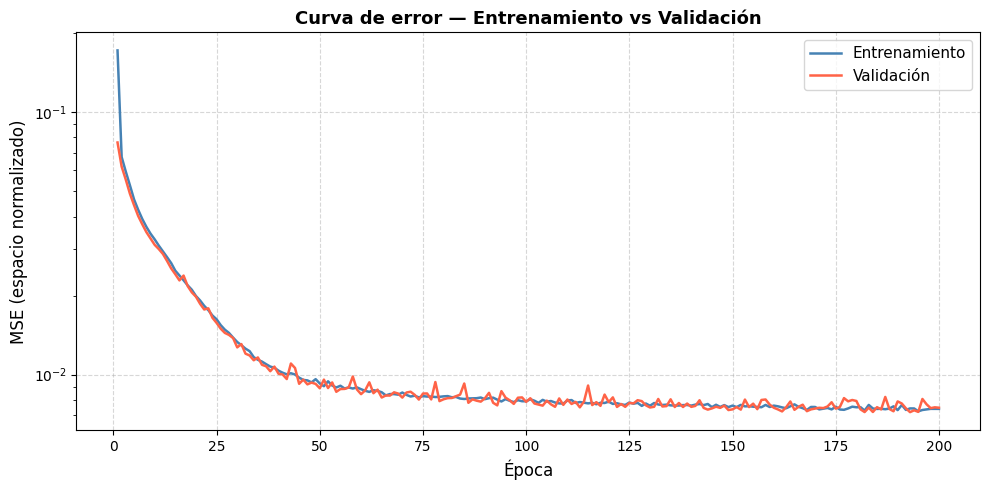


Mejor Val MSE obtenido: 0.007194  (época 193)


In [ ]:
# Curvas de error en entrenamiento y validación (Ítem 6)
fig, ax = plt.subplots(figsize=(10, 5))

epochs_range = range(1, EPOCHS + 1)
ax.plot(epochs_range, train_losses, label='Entrenamiento', color='steelblue',  linewidth=1.8)
ax.plot(epochs_range, val_losses,   label='Validación',    color='tomato',     linewidth=1.8)

ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("MSE (espacio normalizado)", fontsize=12)
ax.set_title("Curva de error — Entrenamiento vs Validación", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_yscale('log')   # escala log para mejor visualización de la convergencia

plt.tight_layout()
plt.show()

print(f"\nMejor Val MSE obtenido: {min(val_losses):.6f}  (época {val_losses.index(min(val_losses))+1})")

Como se adelantaba con los resultados en la celda anterior, se puede ver una caída brusca inicial para el error de entrenamiento y validación. Aunque antes se comentaba que destacaba esta caída para las primeras 20 épocas, gracias a la gráfica se puede ver como la caída es pronunciada hasta aproximadamente las 40 épocas, momento a partir del cual el valor de pérdida se estabiliza en torno a 0.007. Ambas curvas convergen rápidamente y al mantenerse tan solapadas durante todo el proceso se puede considerar que no existe sobreajuste. Por último, las pequeñas oscilaciones en la curva de validación son normales y esperables en este tipo de problemas.

Se probaron capas **BatchNorm1D** intermedias en la arquitectura de la **GNN**, así como distintos valores de **BATCH_SIZE** y de **EPOCHS**, concluyendo que la mejor configuración encontrada fue la que se ha acabado utilizando dado que con otras combinaciones la curva de validación era mucho menos estable y tenía más oscilaciones y perturbaciones.

## Item 7: Predicciones sobre el conjunto de evaluación

Aunque el item 7 dice explícitamente *Reporta los valores de MSE, RMSE, MAE y R² sobre el conjunto de evaluación para cada nodo, así como de forma global para todo el modelo*, he preferido cambiar el título para que sea más acorde al apartado que se va a realizar.

Tras el entrenamiento del modelo se evalúa con el set de evaluación. Para la evaluación se pide evaluar respecto a las siguientes métricas MSE, RMSE, MAE y R². Por lo tanto se crea una nueva función que compute todas las métricas a la vez. Además de esto, se tiene en cuenta también la máscara binaria en este caso, ya que no tiene sentido calcular con estas métricas los valores constantes del dataset. 

In [ ]:
# Predicciones sobre el conjunto de evaluación
model.eval()
pred_list, true_list = [], []

with torch.no_grad():
    for batch in test_loader:
        batch  = batch.to(device)
        B      = batch.num_graphs
        out    = model(batch.x, batch.edge_index)
        pred   = out.view(B, N_BUSES, 2).cpu()
        target = batch.y.view(B, N_BUSES, 2).cpu()
        # Desnormalizar
        pred_list.append(denormalize_Y(pred))
        true_list.append(denormalize_Y(target))

pred_all = torch.cat(pred_list, dim=0)   # (N_test, 14, 2)
true_all = torch.cat(true_list, dim=0)   # (N_test, 14, 2)

# Función de métricas
def compute_metrics(p, t):
    mse  = float(np.mean((p - t) ** 2))
    rmse = float(np.sqrt(mse))
    mae  = float(np.mean(np.abs(p - t)))
    ss_res = np.sum((p - t) ** 2)
    ss_tot = np.sum((t - t.mean()) ** 2)
    r2   = float(1 - ss_res / ss_tot) if ss_tot > 0 else float('nan')
    return mse, rmse, mae, r2

p_np = pred_all.numpy()
t_np = true_all.numpy()

# Métricas por nodo
var_names = ['V (p.u.)', 'δ (°)']
print(f"{'Bus':>4} {'Tipo':>6} {'Variable':>9} {'MSE':>14} {'RMSE':>14} {'MAE':>14} {'R²':>8}")
print("─" * 72)

for bus in range(N_BUSES):
    tipo = bus_type[bus]
    for j, var in enumerate(var_names):
        if mask[bus, j].item() == 0: # nodo/variable fija: no se calculan métricas (se usa la máscara binaria para esto)
            continue
        mse, rmse, mae, r2 = compute_metrics(p_np[:, bus, j], t_np[:, bus, j])
        print(f"{bus:>4} {tipo:>6} {var:>9} {mse:>14.6f} {rmse:>14.6f} {mae:>14.6f} {r2:>8.4f}")

# Métricas globales
print("\n" + "─" * 72)
print("MÉTRICAS GLOBALES")
print("─" * 72)
for j, var in enumerate(var_names):
    valid = [bus for bus in range(N_BUSES) if mask[bus, j].item() == 1]
    p_flat = p_np[:, valid, j].flatten()
    t_flat = t_np[:, valid, j].flatten()
    mse, rmse, mae, r2 = compute_metrics(p_flat, t_flat)
    print(f"{var:>9}: MSE={mse:.6f}  RMSE={rmse:.6f}  MAE={mae:.6f}  R²={r2:.4f}")

 Bus   Tipo  Variable            MSE           RMSE            MAE       R²
────────────────────────────────────────────────────────────────────────
   1     PV     δ (°)       0.076142       0.275939       0.237197   0.7900
   2     PV     δ (°)       0.269030       0.518681       0.433771   0.9014
   3     PQ  V (p.u.)       0.000000       0.000456       0.000353   0.9532
   3     PQ     δ (°)       0.477508       0.691020       0.582304   0.4854
   4     PQ  V (p.u.)       0.000000       0.000554       0.000442   0.9035
   4     PQ     δ (°)       0.046954       0.216689       0.173651   0.9258
   5     PV     δ (°)       0.311130       0.557790       0.478331   0.7260
   6     PQ  V (p.u.)       0.000000       0.000315       0.000245   0.9870
   6     PQ     δ (°)       0.065925       0.256759       0.204819   0.9431
   7     PV     δ (°)       0.219501       0.468509       0.387855   0.8107
   8     PQ  V (p.u.)       0.000001       0.001213       0.000982   0.9341
   8     PQ    

#### Item 9 (primera parte): Conclusiones de evaluación

**Nota**: Aunque el enunciado reserva el Item 9 para comentar los resultados, he preferido comentar los resultados de las métricas ahora que se mostraban los resultados y para el siguiente apartado reservaré un apartado para comentar las conclusiones del histograma. De esta forma queda más ordenado y mejor estructurado el cuaderno.


Como se puede ver, la tabla solo contiene métricas de evaluación de las tensiones y desfases que no son constantes, es por ello que no aparecen métricas de tensión o desfase de **Slack** (bus 0) ni tensiones de ninguno de los nodos **PV** (nodos 1, 2,5 y 7).

Se puede observar como las tensiones se predicen muy bien teniendo en general valores muy bajos de MSE, RMSE y MAE y muy altos de R². Aún así, es remarcable decir que para el R² calculado para la tensión del nodo 11 es muy bajo en comparación al resto de tensiones, con un valor de 0.5273. Esto implica que para este nodo el modelo no es del todo capaz de explicar su variabilidad de forma consistente.

Aún así, a nivel global los valores de las métricas para la tensión son muy buenos por lo que se puede decir que el modelo predice muy bien las tensiones de manera general.


Por otro ldo, ls predicciones de los ángulos δ tienen resultados más irregulares. Como se puede ver, los resultados globales de los ángulos son considerablemente peores que los de las tensiones con un MSE de 0.24 contra el 0.000001 de las tensiones, RMSE de 0.487907 contra el 0.001021 de las tensiones, MAE de 0.383181 contra 0.000740 de las tensiones y un R² de 0.9775 contra el 0.9959 de las tensiones. Aún así siguen siendo valores buenos que indican que el modelo predice con fiabilidad.

Además, es interesante mencionar que el R² de las predicciones del ángulo para el nodo 3 tienen un valor mucho más bajo del normal con una explicabilidad de 0.4854.

Los nodos más problemáticos para las predicciones (con valores de métricas más bajas) son:
- Para tensiones el nodo 11 con el valor de R² extraño comentado antes
- Para grados los nodos 3, 10, 11 y 12 que destacan negativamente en métricas como MSE o R²


Además, el enunciado pide que se responda a la pregunta:

*¿Por qué hemos excluido de las métricas y de la función de coste las dos salidas del nodo slack, así como los voltajes de los nodos PV? Relaciona tu respuesta con el tipo de variables conocidas y desconocidas en el problema de flujo de cargas.*


Aunque ya se ha respondido a la pregunta indirectamente en varias explicaciones anteriores del cuaderno (por ejemplo, cuando se explica la utilidad de creación de máscara), dado que se pide responder a la pregunta, se le va a dedicar un apartado para repetir la respuesta claramente.

Como se veía en la primera parte de la práctica, en el problema de flujo de cargas existen variables conocidas y variables desconocidas. Mientras que las variables desconocidas, son las que nos interesa que el modelo haga la predicción, las variables conocidas, son variables con valores constantes que ya se han comentado en reiteradas ocasiones durante el cuaderno.

En concreto estas variables conocidas y constantes son las siguientes:
- Tensión del nodo **Slack** (fijado como referencia del sistema)
- Ángulo de desfase del nodo **Slack** (fijado como referencia del sistema)
- Tensión de los nodos **PV**

Aunque la tensión de los nodos **PV** es fija, el ángulo de desfase no lo es, por lo tanto δ de los nodos **PV** si debe poder ser predicha por el modelo.

Dado que (V y δ) de **Slack** o (V) de **PV** son constantes, no tiene sentido que el modelo los intente predecir porque siempre tienen el mismo valor conocido, es por ello que se han excluido de las métricas y de la función de coste.

## Item 8: Representación del histograma

El último paso es la representación del histograma normalizado. Como se ha venido haciendo en toda esta parte, se han obviado la tensión y el ángulo de **Slack** así como la tensión de **PV** ya que al ser constantes no nos interesan para esta representación.

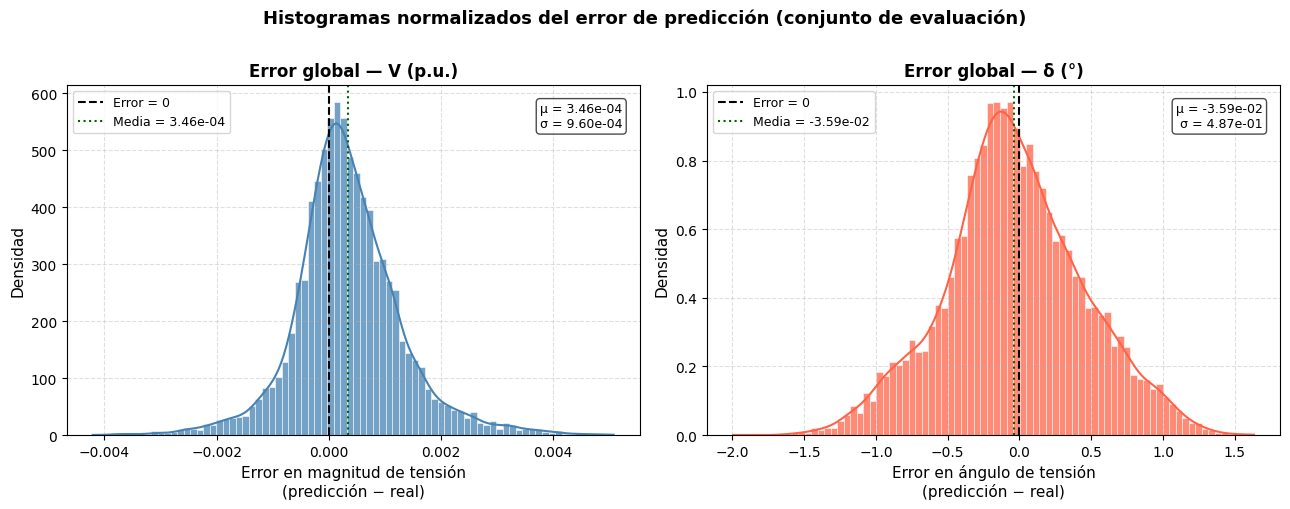

In [ ]:
# Histogramas del error global (Ítem 8)
error_all = p_np - t_np   # (N_test, 14, 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_cfg = [
    (0, 'V (p.u.)',  'Error en magnitud de tensión\n(predicción − real)',  'steelblue'),
    (1, 'δ (°)',     'Error en ángulo de tensión\n(predicción − real)',    'tomato'),
]

for j, var, xlabel, color in plot_cfg:
    ax = axes[j]
    valid = [bus for bus in range(N_BUSES) if mask[bus, j].item() == 1]
    err_flat = error_all[:, valid, j].flatten()

    sns.histplot(err_flat, bins=80, kde=True, stat='density',
                 ax=ax, color=color, edgecolor='white', alpha=0.75)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Error = 0')

    media = err_flat.mean()
    std   = err_flat.std()
    ax.axvline(media, color='darkgreen', linestyle=':', linewidth=1.5,
               label=f'Media = {media:.2e}')

    ax.set_title(f"Error global — {var}", fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Densidad", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

    # Anotación de estadísticos
    ax.text(0.97, 0.95, f"μ = {media:.2e}\nσ = {std:.2e}",
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle("Histogramas normalizados del error de predicción (conjunto de evaluación)",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### Item 9 (segunda parte): Conclusiones histogramas
En primer lugar, se puede ver que la gráfica de la izquierda es estrecha y centrada en 0 con una desviación de 0.00096, lo cuál corrobora lo que comentaba anteriormente sobre el gran rendimiento del modelo para predecir las tensiones. Además se observa que tiene más valores atípicos positivos generando cierta asimetría a la derecha, lo cuál también se puede relacionar con la media que no es exactamente 0 sino ligeramente positiva. Aún así, se puede ver como la gran mayoría de errores están cercanos a 0.

Por otro lado, la gráfica derecha correspondiente al error del ángulo tiene una distribución más ancha, al no estar tan concentrados todos los valores a 0, refleja lo que comentaba anteriormente sobre el peor rendimiento respecto a la predicción de las tensiones. Además, a diferencia de la otra gráfica, esta tiene más valores atípicos en los valores negativos generando cierta asimetría hacia el lado izquierdo, lo cuál también se puede relacionar con la media que no es exactamente 0 sino ligeramente negativa.

Profundizando un poco más en conceptos que se me piden en el enunciado, puede verse una diferencia clara entre la dispersión de las tensiones (0.00096) respecto a las de los ángulos (0.487). Esto confirma que el modelo es mucho más preciso en la predicción de tensiones que en las de ángulos.

Por último, la distribución de error del ángulo presenta cierta multimodalidad. El pico principal está cerca de 0 pero tiene una distribución irregular formando pequeñas irregularidades en forma de "baches" en la curva que se genera como por ejemplo entre -1 y -0.5. Esto muestra que el error no es uniforme entre nodos, esto cuadra con lo que se comentaba antes respecto a los nodos con R² poco comunes (los que tenían valores de 0.4 o 0.6). Aún así son baches muy suaves y que son casi imperceptibles.